In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import networkx.algorithms.approximation as aprox
import pickle

In [2]:
# ex1
def MetPuterii(A, tol, max_iter):
    n = A.shape[0]
    y = np.random.rand(n)
    iter = 0
    err = 1
    
    while err > tol:
        if iter > max_iter:
            break

        y = y / np.linalg.norm(y)
        z = np.dot(A, y)
        z = z / np.linalg.norm(z)
        err = np.abs(1 - np.abs(np.dot(z.T, y)))
        y = z
        iter += 1
        
    return y

In [16]:
# testare
n = 6
A = np.random.rand(n, n)
eigvals, eigvecs = np.linalg.eig(A)

print(f"\n{A}\n")

rez_calc = MetPuterii(A, 1e-6, 10000)

max_val = np.argmax(np.abs(eigvals))
rez_eig = eigvecs[:, max_val]

print("Rezultat Metoda Puterii:", rez_calc)
print("Rezultat eig:", rez_eig)


[[0.8330802  0.93873181 0.65429328 0.93991676 0.73038107 0.16702307]
 [0.17137604 0.38960533 0.30514431 0.08337127 0.91613335 0.16838787]
 [0.40332648 0.09531586 0.19787313 0.95035579 0.88983961 0.75690075]
 [0.69910204 0.90611334 0.13984323 0.40787383 0.1859141  0.90456037]
 [0.33730049 0.99842371 0.0386037  0.06947402 0.02351909 0.06115182]
 [0.40731463 0.32111644 0.83447993 0.80876647 0.55375027 0.12932578]]

Rezultat Metoda Puterii: [0.57467373 0.21174622 0.45043028 0.45425192 0.17444925 0.43040545]
Rezultat eig: [0.57456455+0.j 0.21150577+0.j 0.450694  +0.j 0.45423722+0.j
 0.17413587+0.j 0.43053578+0.j]


In [4]:
# ex 2
# a
with open('grafuri.pickle', 'rb') as f:
    x1, x2, x3 = pickle.load(f)
    
    g1 = nx.convert_matrix.from_numpy_array(x1)
    g2 = nx.convert_matrix.from_numpy_array(x2)
    g3 = nx.convert_matrix.from_numpy_array(x3)

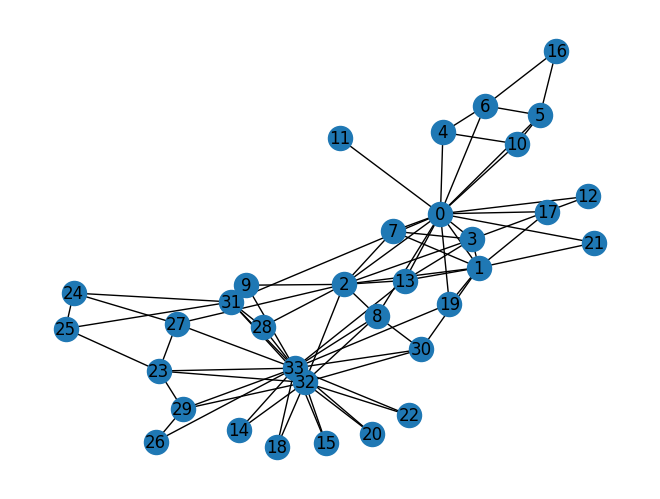

In [5]:
# b
nx.draw(g1, with_labels=True)

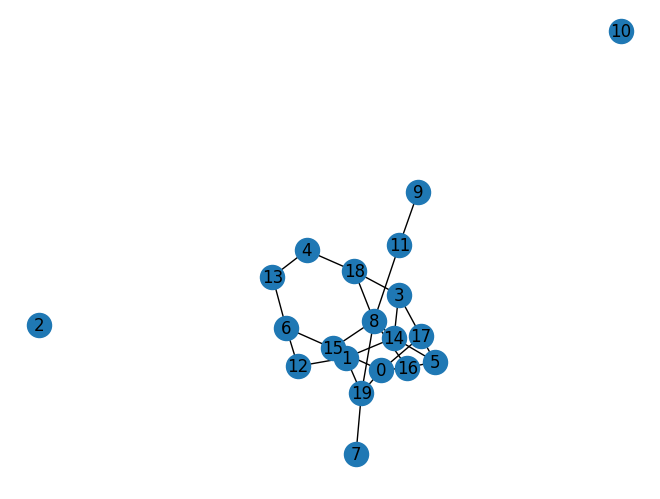

In [6]:
nx.draw(g2, with_labels=True)

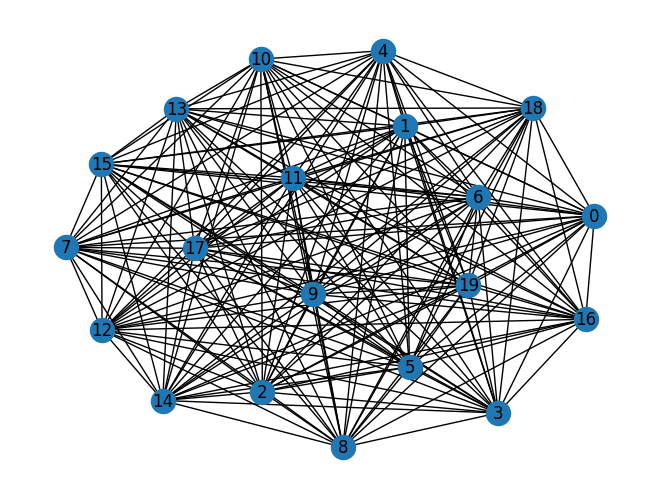

In [7]:
nx.draw(g3, with_labels=True)

In [8]:
# c
np.linalg.eigvals(x1)

array([ 6.72569773e+00+0.00000000e+00j,  4.97707423e+00+0.00000000e+00j,
       -4.48722919e+00+0.00000000e+00j, -3.44793486e+00+0.00000000e+00j,
       -3.11069092e+00+0.00000000e+00j,  2.91650670e+00+0.00000000e+00j,
       -2.43742443e+00+0.00000000e+00j,  2.30908767e+00+0.00000000e+00j,
       -2.09082295e+00+0.00000000e+00j, -1.68768945e+00+0.00000000e+00j,
       -1.44407374e+00+0.00000000e+00j, -1.19242425e+00+0.00000000e+00j,
       -1.04208785e+00+0.00000000e+00j, -7.92406815e-01+0.00000000e+00j,
       -4.18818748e-01+0.00000000e+00j,  1.48615954e+00+0.00000000e+00j,
        1.45305566e+00+0.00000000e+00j,  1.08328639e+00+0.00000000e+00j,
        1.03145042e+00+0.00000000e+00j,  8.34304102e-01+0.00000000e+00j,
        2.99410685e-01+0.00000000e+00j,  4.19729474e-01+0.00000000e+00j,
        6.15840589e-01+0.00000000e+00j, -2.00000000e+00+0.00000000e+00j,
        4.07114663e-16+0.00000000e+00j, -1.89902129e-16+0.00000000e+00j,
       -1.28652956e-16+1.78587966e-16j, -1.28652956

In [9]:
np.linalg.eigvals(x2)

array([ 3.44810371, -3.44810371,  1.94249675,  1.77888578,  1.56348044,
        1.58744316,  1.13370848,  0.69715702,  0.64779166,  0.13209407,
       -0.13209407, -1.94249675, -1.77888578, -1.56348044, -1.58744316,
       -1.13370848, -0.69715702, -0.64779166,  0.        ,  0.        ])

In [10]:
np.linalg.eigvals(x3)

array([-1.+0.00000000e+00j, 19.+0.00000000e+00j, -1.+2.33872637e-16j,
       -1.-2.33872637e-16j, -1.+0.00000000e+00j, -1.+0.00000000e+00j,
       -1.+0.00000000e+00j, -1.+0.00000000e+00j, -1.+0.00000000e+00j,
       -1.+0.00000000e+00j, -1.+0.00000000e+00j, -1.+0.00000000e+00j,
       -1.+0.00000000e+00j, -1.+0.00000000e+00j, -1.+0.00000000e+00j,
       -1.+0.00000000e+00j, -1.+0.00000000e+00j, -1.+0.00000000e+00j,
       -1.+0.00000000e+00j, -1.+0.00000000e+00j])

In [11]:
# d
# completitudinea
def graf_complet(x):
    e = np.linalg.eigvals(x)
    if len(set(np.round(e, 5))) == 2:
        return True
    else:
        return False

In [12]:
print(f"G1 - complet: {graf_complet(x1)}")
print(f"G2 - complet: {graf_complet(x2)}")
print(f"G3 - complet: {graf_complet(x3)}")

G1 - complet: False
G2 - complet: False
G3 - complet: True


In [13]:
# verificarea daca sunt bipartrite
def graf_bipartrit(x):
    e = np.linalg.eigvals(x)
    if np.round(min(e), 5) == np.round(-max(e), 5):
        return True
    else:
        return False

In [14]:
print(f"G1 - bipartrit: {graf_bipartrit(x1)}")
print(f"G2 - bipartrit: {graf_bipartrit(x2)}")
print(f"G3 - bipartrit: {graf_bipartrit(x3)}")

G1 - bipartrit: False
G2 - bipartrit: True
G3 - bipartrit: False


In [15]:
# dimensiunea celei mai mari clici
print(f"Dimensiunea celei mai mari clici in G1(linalg): {int(np.round(max(np.linalg.eigvals(x1).real) + 1))}")
print(f"Dimensiunea celei mai mari clici in G2(linalg): {int(np.round(max(np.linalg.eigvals(x2).real) + 1))}")
print(f"Dimensiunea celei mai mari clici in G3(linalg): {int(np.round(max(np.linalg.eigvals(x3).real) + 1))}")

Dimensiunea celei mai mari clici in G1(linalg): 8
Dimensiunea celei mai mari clici in G2(linalg): 4
Dimensiunea celei mai mari clici in G3(linalg): 20
